In [38]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("All libraries loaded successfully")

All libraries loaded successfully


In [39]:
stocks_input = input("Enter stock tickers separated by commas (example: HDFCBANK.NS,ICICIBANK.NS,TCS.NS): ")

stocks = [s.strip() for s in stocks_input.split(",")]

print("Selected stocks:", stocks)

Selected stocks: ['HDFCBANK.NS', 'ICICIBANK.NS', 'ITC.NS', 'RELIANCE.NS', 'TCS.NS']


In [40]:
data = yf.download(stocks, start="2018-01-01")

data = data["Close"]

data.tail()

[*********************100%***********************]  5 of 5 completed


Ticker,HDFCBANK.NS,ICICIBANK.NS,ITC.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2026-03-09,840.700012,1278.400024,306.000000,1424.000000,2527.399902
2026-03-10,849.450012,1311.900024,309.049988,1408.800049,2513.100098
2026-03-11,833.950012,1294.599976,309.000000,1390.199951,2464.899902
2026-03-12,832.750000,1266.500000,304.100006,1392.199951,2442.399902
2026-03-13,817.000000,1254.800049,301.450012,1380.699951,2410.500000


In [41]:
daily_returns = data.pct_change()

daily_returns.tail()

Ticker,HDFCBANK.NS,ICICIBANK.NS,ITC.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2026-03-09,-0.019077,-0.026648,-0.011947,0.013667,-0.011808
2026-03-10,0.010408,0.026205,0.009967,-0.010674,-0.005658
2026-03-11,-0.018247,-0.013187,-0.000162,-0.013203,-0.019180
2026-03-12,-0.001439,-0.021706,-0.015858,0.001439,-0.009128
2026-03-13,-0.018913,-0.009238,-0.008714,-0.008260,-0.013061


The table above shows the daily percentage returns for each stock. The daily returns are obtaind using the function pct_change.

In [42]:
momentum = data.pct_change(90)
momentum.tail()

Ticker,HDFCBANK.NS,ICICIBANK.NS,ITC.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2026-03-09,-0.162274,-0.062138,-0.252422,-0.042303,-0.158460
2026-03-10,-0.157166,-0.042688,-0.251596,-0.063422,-0.163139
2026-03-11,-0.164504,-0.049765,-0.246625,-0.066040,-0.173159
2026-03-12,-0.156538,-0.058574,-0.261394,-0.063375,-0.186789
2026-03-13,-0.176951,-0.068033,-0.256510,-0.070048,-0.186449


performance of the stocks in past 90 days

In [43]:
ranks=momentum.rank(axis=1,ascending=False)
ranks.tail()

Ticker,HDFCBANK.NS,ICICIBANK.NS,ITC.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2026-03-09,4.0,2.0,5.0,1.0,3.0
2026-03-10,3.0,1.0,5.0,2.0,4.0
2026-03-11,3.0,1.0,5.0,2.0,4.0
2026-03-12,3.0,1.0,5.0,2.0,4.0
2026-03-13,3.0,1.0,5.0,2.0,4.0


Gives insight on which stock to buy,ie ranks them from top as 1 to 5


In [44]:
top_stocks=ranks<=2
top_stocks.tail()

Ticker,HDFCBANK.NS,ICICIBANK.NS,ITC.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2026-03-09,False,True,False,True,False
2026-03-10,False,True,False,True,False
2026-03-11,False,True,False,True,False
2026-03-12,False,True,False,True,False
2026-03-13,False,True,False,True,False


give top 2 stocks of the day,i.e if it gives true include in your portfolio

In [45]:
strategy_returns = (daily_returns * top_stocks.shift(1)).mean(axis=1)

strategy_returns.tail()


Date
2026-03-09   -0.002596
2026-03-10    0.003106
2026-03-11   -0.005278
2026-03-12   -0.004053
2026-03-13     -0.0035
dtype: object

we use shift because we take data from yesterday during closing and invest today with that,So we shift by 1 fortop_stocks data

In [46]:
strategy_returns = strategy_returns.astype(float)


In [47]:
initial_investment = float(input("Enter initial investment amount: "))
initial_investment

100000.0

In [48]:
portfolio = initial_investment * (1 + strategy_returns).cumprod()

portfolio.tail()

Date
2026-03-09    157900.312094
2026-03-10    158390.766483
2026-03-11    157554.785965
2026-03-12    156916.156997
2026-03-13    156367.002958
dtype: float64

This shows value of your Portfolio if your investment started in 2018


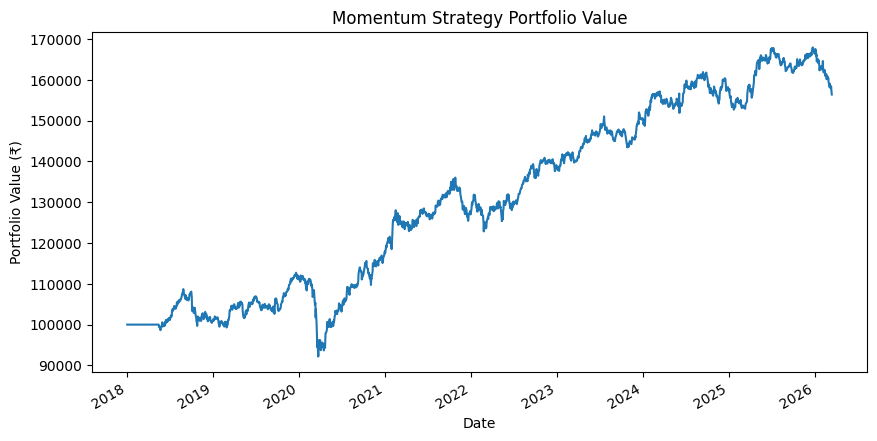

In [49]:
portfolio.plot(figsize=(10,5))

plt.title("Momentum Strategy Portfolio Value")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (₹)")

plt.show()

In [50]:
sharpe = strategy_returns.mean() / strategy_returns.std() * (252 ** 0.5)

print("Sharpe Ratio:", sharpe)

Sharpe Ratio: 0.712552528193452


Sharpe ratio is basically a measure of your returns per risk

In [51]:
rolling_max = portfolio.cummax()
drawdown = (portfolio - rolling_max) / rolling_max

In [52]:
max_drawdown = drawdown.min()

print("Maximum Drawdown:", max_drawdown)

Maximum Drawdown: -0.18214368827173463


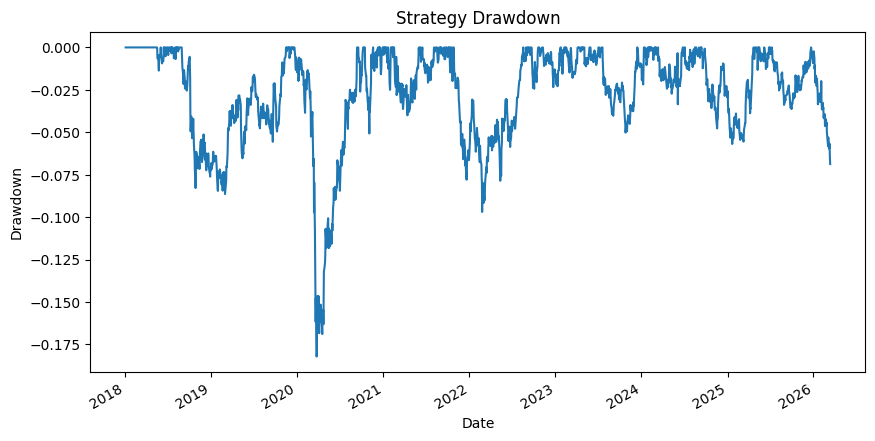

In [53]:
drawdown.plot(figsize=(10,5))
plt.title("Strategy Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.show()

This shows how worse a drop was in your portfolio during the years

In [54]:
nifty = yf.download("^NSEI", start="2018-01-01")["Close"]

nifty_returns = nifty.pct_change()

nifty_portfolio = initial_investment * (1 + nifty_returns).cumprod()

[*********************100%***********************]  1 of 1 completed


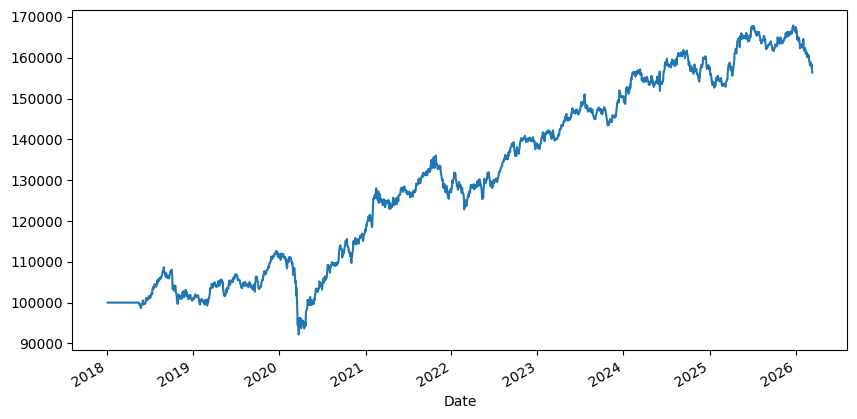

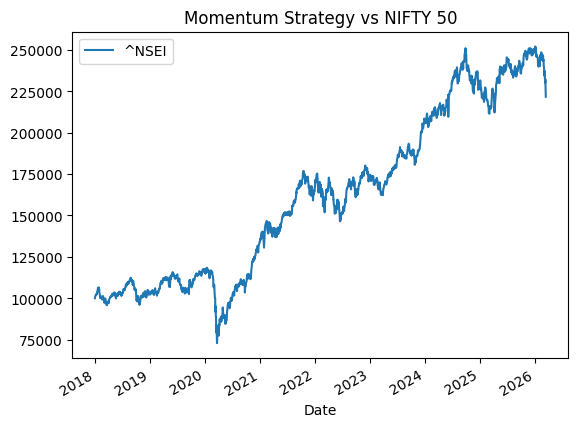

In [55]:
plt.figure(figsize=(10,5))

portfolio.plot(label="Momentum Strategy")
nifty_portfolio.plot(label="NIFTY 50")

plt.title("Momentum Strategy vs NIFTY 50")
plt.legend()
plt.show()

these plots show returns of market and your portfolios and if the your portfolio really beat the market

In [57]:
print("Initial Investment:", initial_investment)
print("Final Portfolio Value:", portfolio.iloc[-1])
total_return = (portfolio.iloc[-1] / initial_investment - 1) * 100
print("Total Return:", total_return, "%")
print("Sharpe Ratio:", sharpe)
print("Maximum Drawdown:", max_drawdown)

Initial Investment: 100000.0
Final Portfolio Value: 156367.00295808574
Total Return: 56.36700295808574 %
Sharpe Ratio: 0.712552528193452
Maximum Drawdown: -0.18214368827173463
